<a href="https://colab.research.google.com/github/krishbisen/ML-DL/blob/main/improvement_blocksv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Score-boost blocks for the Home Credit tutorial
Drop these cells **after Section 1 (setup + path check)** and use them *instead of* Sections 2.2 → 6.1.
Metric = ROC-AUC. Each block logs its CV score into `scores`, so you can see what actually helped (final chart at the end).

| Block | What it does | Why it helps |
|---|---|---|
| A | Load **all** features | More signal than 5 columns |
| B | Clean junk values (XNA, 365243, car age ≥ 60) | Stops fake values acting as real ones |
| C | Engineered features (ratios, EXT_SOURCE stats) | Credit-risk data is ratio-driven |
| D | Encoding (frequency + native categoricals) | Keeps category info without 1000 dummy columns |
| E | Model shootout: Decision Tree vs RF vs LightGBM | Pick the model with evidence |
| F | Stratified 5-fold CV + early stopping | Reliable score, no overfitting |
| G | Random-search tuning | Squeezes out the last points |
| H | Seed-averaging + submission | Stable final predictions |

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/00_GCIGlobal/Competition"

/content/drive/MyDrive/00_GCIGlobal/Competition


## A. Load everything

In [6]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings("ignore")

current_dir = Path(os.getcwd())
train = pd.read_csv(current_dir / "input" / "train.csv")
test = pd.read_csv(current_dir / "input" / "test.csv")
sample_sub = pd.read_csv(current_dir / "input" / "sample_submission.csv")

y = train["TARGET"].values
ID_COL = "SK_ID_CURR"

# Stack train+test so every encoding/category is built on the same schema
feat_train = train.drop(columns=["TARGET"])
df = pd.concat([feat_train, test[feat_train.columns]], keys=["train", "test"])
df = df.drop(columns=[c for c in [ID_COL] if c in df.columns])

scores = {}   # stage name -> CV AUC
print("features:", df.shape[1], "| train rows:", len(train), "| test rows:", len(test))
print(f"default rate: {y.mean():.4f}")

features: 32 | train rows: 171202 | test rows: 61500
default rate: 0.0807


## B. Cleaning (fix the junk the EDA found)

In [7]:
# 1) "XNA" is a missing-value marker
obj_cols = df.select_dtypes(include=["object", "string"]).columns
df[obj_cols] = df[obj_cols].replace("XNA", np.nan)

# 2) 365243 days (~1000 years) in DAYS_EMPLOYED is a placeholder, not a real value
if "DAYS_EMPLOYED" in df.columns:
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

# 3) Car age >= 60 treated as outlier -> NaN (trees handle NaN natively, no need to bin/one-hot)
if "OWN_CAR_AGE" in df.columns:
    df.loc[df["OWN_CAR_AGE"] >= 60, "OWN_CAR_AGE"] = np.nan

print("missing cells after cleaning:", int(df.isna().sum().sum()))

missing cells after cleaning: 602463


## C. Feature engineering
Everything is guarded with `if col exists`, so it works with whichever of the 30 features you have.
Ratios (credit vs income, payment vs income) and combos of the `EXT_SOURCE_*` scores are the classic winners on this dataset.

In [8]:
def has(*cols):
    return all(c in df.columns for c in cols)

def safe_div(a, b):
    return a / b.replace(0, np.nan)

new = {}

# --- money ratios
if has("AMT_CREDIT", "AMT_INCOME_TOTAL"):
    new["CREDIT_TO_INCOME"] = safe_div(df["AMT_CREDIT"], df["AMT_INCOME_TOTAL"])
if has("AMT_ANNUITY", "AMT_INCOME_TOTAL"):
    new["ANNUITY_TO_INCOME"] = safe_div(df["AMT_ANNUITY"], df["AMT_INCOME_TOTAL"])
if has("AMT_ANNUITY", "AMT_CREDIT"):
    new["ANNUITY_TO_CREDIT"] = safe_div(df["AMT_ANNUITY"], df["AMT_CREDIT"])      # ~ 1 / loan term
if has("AMT_GOODS_PRICE", "AMT_CREDIT"):
    new["GOODS_TO_CREDIT"] = safe_div(df["AMT_GOODS_PRICE"], df["AMT_CREDIT"])
if has("AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS"):
    new["INCOME_PER_PERSON"] = safe_div(df["AMT_INCOME_TOTAL"], df["CNT_FAM_MEMBERS"])
if "AMT_INCOME_TOTAL" in df.columns:
    new["LOG_INCOME"] = np.log1p(df["AMT_INCOME_TOTAL"])

# --- time features
if "DAYS_BIRTH" in df.columns:
    new["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25
if has("DAYS_EMPLOYED", "DAYS_BIRTH"):
    new["EMPLOYED_TO_AGE"] = safe_div(df["DAYS_EMPLOYED"], df["DAYS_BIRTH"])
if "DAYS_EMPLOYED" in df.columns:
    new["YEARS_EMPLOYED"] = -df["DAYS_EMPLOYED"] / 365.25

# --- external score combos (strongest predictors in this competition)
ext = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] if c in df.columns]
if len(ext) >= 2:
    new["EXT_MEAN"] = df[ext].mean(axis=1)
    new["EXT_MIN"] = df[ext].min(axis=1)
    new["EXT_MAX"] = df[ext].max(axis=1)
    new["EXT_STD"] = df[ext].std(axis=1)
    new["EXT_PROD"] = df[ext].prod(axis=1, skipna=True)
if "EXT_SOURCE_2" in df.columns and "DAYS_BIRTH" in df.columns:
    new["EXT2_X_AGE"] = df["EXT_SOURCE_2"] * (-df["DAYS_BIRTH"] / 365.25)

# --- how many values are missing in a row is itself informative
new["N_MISSING"] = df.isna().sum(axis=1)

new_df = pd.DataFrame(new, index=df.index).replace([np.inf, -np.inf], np.nan)
new_cols = list(new_df.columns)
df = pd.concat([df, new_df], axis=1)
print(f"added {len(new_cols)} features:", new_cols)

added 16 features: ['CREDIT_TO_INCOME', 'ANNUITY_TO_INCOME', 'ANNUITY_TO_CREDIT', 'GOODS_TO_CREDIT', 'INCOME_PER_PERSON', 'LOG_INCOME', 'AGE_YEARS', 'EMPLOYED_TO_AGE', 'YEARS_EMPLOYED', 'EXT_MEAN', 'EXT_MIN', 'EXT_MAX', 'EXT_STD', 'EXT_PROD', 'EXT2_X_AGE', 'N_MISSING']


## D. Encoding
* **Frequency encoding** (your count encoding, but for every text column) -> a numeric column
* **`category` dtype** -> LightGBM splits on categories directly, no dummy explosion
* One row-wise rule for everything: encode on train+test together (that's unsupervised, so no leakage)

In [9]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
for c in cat_cols:
    df[c + "_FREQ"] = df[c].map(df[c].value_counts()).astype(float)
    df[c] = df[c].astype("category")

X = df.loc["train"].reset_index(drop=True)
X_test = df.loc["test"].reset_index(drop=True)
print("categorical:", cat_cols)
print("final matrix:", X.shape, X_test.shape)

# numeric-only copy (Decision Tree / Random Forest can't eat categories or NaN)
def to_numeric(frame, medians=None):
    out = frame.copy()
    for c in cat_cols:
        out[c] = out[c].cat.codes
    medians = out.median() if medians is None else medians
    return out.fillna(medians), medians

X_num, med = to_numeric(X)
X_test_num, _ = to_numeric(X_test, med)   # fill test with TRAIN medians

categorical: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
final matrix: (171202, 56) (61500, 56)


## E. Model shootout (Decision Tree vs Random Forest vs LightGBM)
Same 3-fold stratified split for all of them, so the comparison is fair.

In [10]:
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

candidates = {
    "Decision Tree": (DecisionTreeClassifier(max_depth=6, min_samples_leaf=200,
                                             class_weight="balanced", random_state=0), X_num),
    "Random Forest": (RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=50,
                                             class_weight="balanced_subsample", n_jobs=-1,
                                             random_state=0), X_num),
    "LightGBM (default-ish)": (lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05,
                                                  num_leaves=31, colsample_bytree=0.7,
                                                  subsample=0.8, subsample_freq=1,
                                                  random_state=0, verbose=-1), X),
}

for name, (model, data) in candidates.items():
    auc = cross_val_score(model, data, y, cv=cv3, scoring="roc_auc", n_jobs=1).mean()
    scores[name] = auc
    print(f"{name:<24} AUC = {auc:.4f}")

# does feature engineering actually help? (same LightGBM, with vs without new columns)
raw_cols = [c for c in X.columns if c not in new_cols]
auc_raw = cross_val_score(candidates["LightGBM (default-ish)"][0], X[raw_cols], y,
                          cv=cv3, scoring="roc_auc").mean()
scores["LightGBM - no engineered feats"] = auc_raw
print(f"{'LightGBM w/o new feats':<24} AUC = {auc_raw:.4f}  (gain from FE: {scores['LightGBM (default-ish)'] - auc_raw:+.4f})")

Decision Tree            AUC = 0.7153
Random Forest            AUC = 0.7418
LightGBM (default-ish)   AUC = 0.7541
LightGBM w/o new feats   AUC = 0.7459  (gain from FE: +0.0082)


## F. Proper CV loop with early stopping
`n_estimators` is set high and **early stopping** picks the right number of trees per fold, so you don't have to guess.
Returns out-of-fold predictions (an honest score on *every* training row), averaged test predictions and feature importance.

In [11]:
def run_cv(params, X, y, X_test, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.zeros(len(X))
    pred = np.zeros(len(X_test))
    imp = pd.Series(0.0, index=X.columns)
    for tr, va in skf.split(X, y):
        model = lgb.LGBMClassifier(**params, n_estimators=3000, random_state=seed, verbose=-1)
        model.fit(X.iloc[tr], y[tr],
                  eval_set=[(X.iloc[va], y[va])], eval_metric="auc",
                  callbacks=[lgb.early_stopping(100, verbose=False)])
        oof[va] = model.predict_proba(X.iloc[va])[:, 1]
        pred += model.predict_proba(X_test)[:, 1] / n_splits
        imp += pd.Series(model.booster_.feature_importance("gain"), index=X.columns) / n_splits
    return roc_auc_score(y, oof), oof, pred, imp

base_params = dict(learning_rate=0.05, num_leaves=31, min_child_samples=50,
                   subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
                   reg_lambda=1.0)
auc_base, oof_base, pred_base, imp_base = run_cv(base_params, X, y, X_test)
scores["LightGBM 5-fold + early stop"] = auc_base
print(f"5-fold OOF AUC = {auc_base:.4f}")

5-fold OOF AUC = 0.7576


## G. Hyper-parameter tuning (random search, written from scratch)
Search on 3 folds with a higher learning rate (fast), then retrain the winner with a low learning rate.
Increase `N_TRIALS` if you have time (20-40 is a good range).

In [12]:
N_TRIALS = 15
rng = np.random.default_rng(7)

def sample_params():
    return dict(
        learning_rate=0.08,                                   # fast during search
        num_leaves=int(rng.choice([15, 31, 63, 127])),
        max_depth=int(rng.choice([-1, 6, 8, 10])),
        min_child_samples=int(rng.choice([20, 50, 100, 200])),
        subsample=float(rng.uniform(0.6, 1.0)), subsample_freq=1,
        colsample_bytree=float(rng.uniform(0.4, 1.0)),
        reg_alpha=float(rng.choice([0, 0.1, 1, 5])),
        reg_lambda=float(rng.choice([0, 1, 5, 20])),
    )

trials = []
for i in range(N_TRIALS):
    p = sample_params()
    auc, *_ = run_cv(p, X, y, X_test.iloc[:5], n_splits=3, seed=1)
    trials.append((auc, p))
    print(f"trial {i+1:>2}/{N_TRIALS}  AUC={auc:.4f}  leaves={p['num_leaves']:<3} "
          f"depth={p['max_depth']:<3} mcs={p['min_child_samples']:<3} col={p['colsample_bytree']:.2f}")

trials.sort(key=lambda t: t[0], reverse=True)
best_params = {**trials[0][1], "learning_rate": 0.03}      # slow & precise for the final fit
print("\nbest params:", best_params)

auc_tuned, oof_tuned, pred_tuned, imp_tuned = run_cv(best_params, X, y, X_test)
scores["LightGBM tuned (lr 0.03)"] = auc_tuned
print(f"tuned 5-fold OOF AUC = {auc_tuned:.4f}  (vs untuned {auc_base:.4f})")

trial  1/15  AUC=0.7544  leaves=127 depth=8   mcs=100 col=0.54
trial  2/15  AUC=0.7530  leaves=31  depth=6   mcs=200 col=0.89
trial  3/15  AUC=0.7563  leaves=15  depth=6   mcs=200 col=0.55
trial  4/15  AUC=0.7552  leaves=31  depth=6   mcs=100 col=1.00
trial  5/15  AUC=0.7545  leaves=63  depth=8   mcs=50  col=0.50
trial  6/15  AUC=0.7521  leaves=63  depth=-1  mcs=20  col=0.71
trial  7/15  AUC=0.7511  leaves=127 depth=10  mcs=200 col=0.70
trial  8/15  AUC=0.7547  leaves=15  depth=10  mcs=20  col=0.82
trial  9/15  AUC=0.7567  leaves=63  depth=6   mcs=50  col=0.49
trial 10/15  AUC=0.7546  leaves=31  depth=10  mcs=200 col=0.91
trial 11/15  AUC=0.7565  leaves=15  depth=8   mcs=50  col=0.70
trial 12/15  AUC=0.7533  leaves=127 depth=8   mcs=50  col=0.44
trial 13/15  AUC=0.7555  leaves=63  depth=6   mcs=20  col=0.63
trial 14/15  AUC=0.7548  leaves=127 depth=6   mcs=100 col=0.78
trial 15/15  AUC=0.7519  leaves=127 depth=-1  mcs=100 col=0.64

best params: {'learning_rate': 0.03, 'num_leaves': 63,

## H. Seed averaging -> final predictions -> submission
Same model, 3 different fold/seed splits, averaged. Reduces variance for free.
The submission cell keeps the format of your original Section 6.2.

In [13]:
SEEDS = [11, 22, 33]
oofs, preds = [], []
for s in SEEDS:
    auc_s, oof_s, pred_s, _ = run_cv(best_params, X, y, X_test, seed=s)
    oofs.append(oof_s); preds.append(pred_s)
    print(f"seed {s}: AUC = {auc_s:.4f}")

oof_final = np.mean(oofs, axis=0)
pred = np.mean(preds, axis=0)
scores["Tuned + 3-seed average"] = roc_auc_score(y, oof_final)
print(f"\nseed-averaged OOF AUC = {scores['Tuned + 3-seed average']:.4f}")

# ---- submission (same format as the tutorial)
sample_sub["TARGET"] = pred
output_dir = current_dir / "output"
os.makedirs(output_dir, exist_ok=True)
sample_sub.to_csv(output_dir / "submission1.csv", index=False)
print("saved:", output_dir / "submission1.csv", sample_sub.shape)

seed 11: AUC = 0.7600
seed 22: AUC = 0.7589
seed 33: AUC = 0.7606

seed-averaged OOF AUC = 0.7617
saved: /content/drive/MyDrive/00_GCIGlobal/Competition/output/submission1.csv (61500, 2)


## Diagrams: what helped, ROC curve, what the model uses

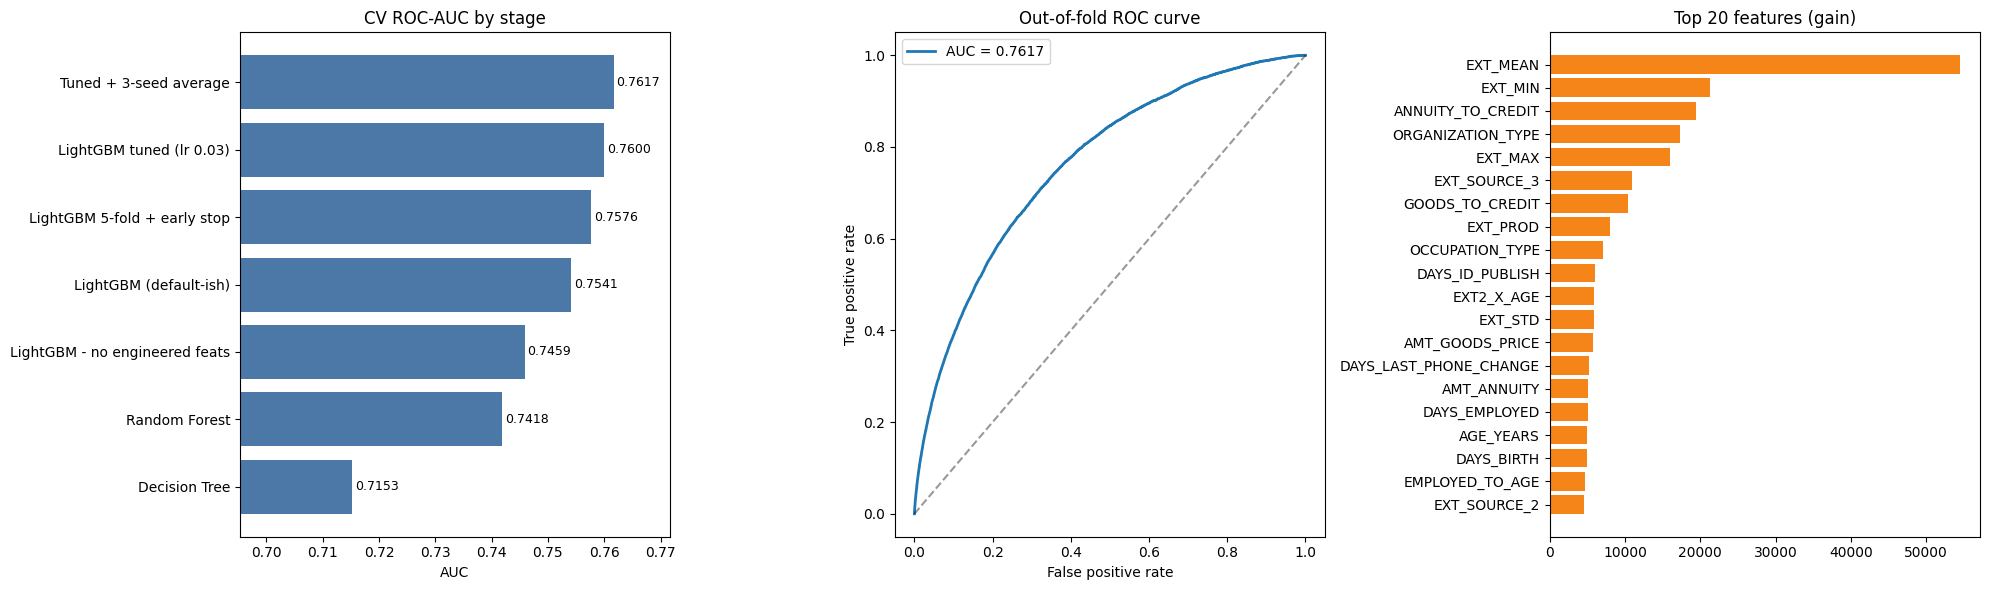

In [14]:
from sklearn.metrics import roc_curve
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# 1) score ladder
s = pd.Series(scores).sort_values()
ax[0].barh(s.index, s.values, color="#4C78A8")
ax[0].set_xlim(max(0.5, s.min() - 0.02), s.max() + 0.01)
for i, v in enumerate(s.values):
    ax[0].text(v + 0.0005, i, f"{v:.4f}", va="center", fontsize=9)
ax[0].set_title("CV ROC-AUC by stage"); ax[0].set_xlabel("AUC")

# 2) ROC curve (out-of-fold)
fpr, tpr, _ = roc_curve(y, oof_final)
ax[1].plot(fpr, tpr, lw=2, label=f"AUC = {scores['Tuned + 3-seed average']:.4f}")
ax[1].plot([0, 1], [0, 1], "k--", alpha=.4)
ax[1].set_title("Out-of-fold ROC curve"); ax[1].set_xlabel("False positive rate")
ax[1].set_ylabel("True positive rate"); ax[1].legend()

# 3) top features by gain
top = imp_tuned.sort_values(ascending=False).head(20)[::-1]
ax[2].barh(top.index, top.values, color="#F58518")
ax[2].set_title("Top 20 features (gain)")

plt.tight_layout(); plt.show()

## What to try next (in order of payoff)
1. **Add the remaining raw features** - block A already loads all of them, nothing to change.
2. **Target-style aggregates**: mean `TARGET` per `ORGANIZATION_TYPE` / education / occupation, computed **inside each CV fold only** (otherwise you leak the answer).
3. **More trials** in block G (`N_TRIALS = 40`).
4. **Blend** LightGBM with a second boosted model (XGBoost / CatBoost) and average the ranks.
5. If AUC (CV) goes up but the leaderboard doesn't: you're overfitting the CV - check you didn't use `TARGET`-derived info outside the folds.